# System identification

Step 5.9. A dynamic single-track model with saturating tires, fitted on the
identification runs of step 5.8 and checked on the validation runs. Mass, CG,
yaw inertia (`inertia.ipynb`) and wheel radius (`kinematic_model.ipynb`) are
fixed; only the tire parameters are fitted.

## Model

Body frame at the CG, $x$ forward, $y$ left. States: lateral velocity $v_y$, yaw
rate $r$, and the steering angle $\delta$, which follows the command with a lag.
Inputs: steering command, rear wheel speed $u$ from the encoders, and $v_x$ from
the overhead video.

**Front**, one rolling tire:

$$\alpha_f = \delta - \arctan\frac{v_y + l_f r}{v_x}, \qquad
F_{yf} = \mu_f N_f \sin\big(C \arctan(B_f \alpha_f)\big)$$

**Rear**, the spool: two wheels at $\pm T/2$, both turning at the surface speed
$u$. Wheel $i$ sees the ground at $(v_x \mp \tfrac{T}{2} r,\; v_y - l_r r)$ and
slips by

$$\sigma_i = \frac{(v_{x,i} - u,\; v_{y,i})}{u}, \qquad
\mathbf{F}_i = -\frac{\mu_r N_r}{2} \sin\big(C \arctan(B_r |\sigma_i|)\big)
\frac{\sigma_i}{|\sigma_i|}$$

so each rear tire pushes against its own sliding direction: sideways when the
car turns, forward when the wheels spin. The forward forces of the two wheels
differ in a turn and give a yaw moment.

**Motion**, with $v_x$ given:

$$m(\dot v_y + v_x r) = F_{yf}\cos\delta + F_{y,L} + F_{y,R}$$
$$I_z \dot r = l_f F_{yf}\cos\delta - l_r (F_{y,L} + F_{y,R}) + \tfrac{T}{2}(F_{x,R} - F_{x,L})$$
$$\dot\delta = (\delta_{cmd} - \delta)/\tau$$

Static axle loads $N_f = m g\, l_r/L$, $N_r = m g\, l_f/L$. Fitted: $\mu_f, B_f,
\mu_r, B_r, C$.

A single rear contact point does not work: the spool makes the rear wheels turn
~15% faster than the axle moves even in slow grip turns (inner wheel slipping
forward, outer backward), and one contact point reads that as wheelspin.
Fitted on the drift run it needed mu = 2 against 0.25 measured and diverged on
validation. With two wheels the slips cancel in a grip turn and add up in a
donut.

Two inputs are provisional. The steering map point at 0.40 rad is read from the
kinematics of the 5.8 runs (24.4 deg), not measured; the static map only has 17
and 30 deg on this side. The steering lag of 0.15 s comes from a fit on the grip
runs. Both get measured directly next.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

M, IZ = 2.015, 0.0125                 # inertia.ipynb
LF, LR, L, T = 0.0986, 0.0744, 0.173, 0.1745
G = 9.81
NF, NR = M * G * LR / L, M * G * LF / L

# steering map (kinematic_model.ipynb), plus the provisional point at 22.92 deg command
CMD = np.radians([0, 8.59, 17.19, 22.92, 29.79])
DEL = np.radians([0.63, 9.33, 17.83, 24.4, 27.43])
TAU = 0.15                            # s, provisional steering lag


def load(name, t0, t1):
    df = pd.read_parquet(f'../data/sysid/{name}.parquet')
    df = df[(df['t'] >= t0) & (df['t'] <= t1)].reset_index(drop=True)
    df['vx'] = (df['v_cg'] * np.cos(np.radians(df['beta_cg']))).interpolate().bfill().ffill()
    df['u'] = df['v_wheels'].interpolate().bfill().ffill()
    df['delta'] = np.interp(df['cmd_steer'], CMD, DEL)
    return df


WINDOWS = {'id_steps': (3, 31), 'id_chirp': (3, 25.5), 'id_drift': (2.5, 15.5),
           'val_steps': (3, 31), 'val_chirp': (3, 25.5), 'val_drift': (2.5, 15.5), 'release': (2.5, 13.8)}
runs = {name: load(name, *w) for name, w in WINDOWS.items()}

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def rear_wheel(vx, vy, u, mu, b, c):
    sx, sy = (vx - u) / max(u, 0.1), vy / max(u, 0.1)
    s = np.hypot(sx, sy) + 1e-9
    f = mu * NR / 2 * np.sin(c * np.arctan(b * s))
    return -f * sx / s, -f * sy / s


def rhs(x, p, vx, u, delta_cmd):
    mu_f, bf, mu_r, br, c = p
    vy, r, d = x
    fyf = mu_f * NF * np.sin(c * np.arctan(bf * (d - np.arctan((vy + LF * r) / vx))))
    fxl, fyl = rear_wheel(vx - T / 2 * r, vy - LR * r, u, mu_r, br, c)
    fxr, fyr = rear_wheel(vx + T / 2 * r, vy - LR * r, u, mu_r, br, c)
    vy_dot = (fyf * np.cos(d) + fyl + fyr) / M - vx * r
    r_dot = (LF * fyf * np.cos(d) - LR * (fyl + fyr) + T / 2 * (fxr - fxl)) / IZ
    return np.array([vy_dot, r_dot, (delta_cmd - d) / TAU])


def simulate(p, df, h=0.002):
    # fixed-step RK4, inputs held over each 20 ms sample; starts from the measured state
    t, vx, u, dc = df['t'].to_numpy(), df['vx'].to_numpy(), df['u'].to_numpy(), df['delta'].to_numpy()
    beta0 = df['beta_cg'][:25]
    b0 = np.radians(beta0.mean()) if beta0.notna().any() else np.arctan(LR * df['r'][0] / vx[0])
    x = np.array([vx[0] * np.tan(b0), df['r'][:25].mean(), dc[0]])
    out = np.zeros((len(t), 3))
    out[0] = x
    for i in range(len(t) - 1):
        n = max(1, round((t[i + 1] - t[i]) / h))
        hh = (t[i + 1] - t[i]) / n
        for _ in range(n):
            k1 = rhs(x, p, vx[i], u[i], dc[i])
            k2 = rhs(x + hh / 2 * k1, p, vx[i], u[i], dc[i])
            k3 = rhs(x + hh / 2 * k2, p, vx[i], u[i], dc[i])
            k4 = rhs(x + hh * k3, p, vx[i], u[i], dc[i])
            x = x + hh / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        if not np.isfinite(x).all() or abs(x[1]) > 50:
            return np.full((len(t), 3), np.nan)
        out[i + 1] = x
    return out


def beta_deg(sim, df):
    return np.degrees(np.arctan2(sim[:, 0], df['vx']))

## Fit

Least squares on yaw rate (weight 1/0.2 rad/s) and CG sideslip (1/2 deg) over
the three identification runs together, so one parameter set has to cover grip
and drift. The three starts tried while setting this up all ended at the same
point.

In [3]:
def residuals(p, dfs):
    res = []
    for df in dfs:
        s = simulate(p, df)
        if not np.isfinite(s).all():
            return np.full(sum(2 * len(d) for d in dfs), 1e3)
        b = df['beta_cg'].to_numpy()
        ok = np.isfinite(b)
        res.append((s[:, 1] - df['r']) / 0.2)
        res.append(np.r_[(beta_deg(s, df)[ok] - b[ok]) / 2.0, np.zeros((~ok).sum())])
    return np.concatenate(res)


ids = [runs['id_steps'], runs['id_chirp'], runs['id_drift']]
fit = least_squares(residuals, [0.4, 15, 0.25, 15, 1.0], args=(ids,),
                    bounds=([0.05, 0.5, 0.05, 0.5, 0.5], [1.5, 60, 1.5, 60, 2.0]),
                    x_scale=[0.1, 5, 0.1, 5, 0.2], diff_step=1e-3)
p = fit.x
cov = np.linalg.pinv(fit.jac.T @ fit.jac) * 2 * fit.cost / (len(fit.fun) - len(p))
params = pd.DataFrame({'value': p, '1 sigma': np.sqrt(np.diag(cov))},
                      index=['mu_f', 'B_f', 'mu_r', 'B_r', 'C']).round(3)
params

,value,1 sigma
mu_f,0.370,0.002
B_f,60.000,6.865
mu_r,0.266,0.001
B_r,14.272,1.529
C,1.045,0.062


In [4]:
# cornering stiffness at zero slip: dF/dalpha = mu N B C
print(f"front {p[0] * NF * p[1] * p[4]:.0f} N/rad, rear axle {p[2] * NR * p[3] * p[4]:.0f} N per unit slip")

front 197 N/rad, rear axle 45 N per unit slip


**mu_r = 0.27**, the rear sliding friction, lands 7% from the 0.25 of the
straight launches (`handling.ipynb`), an independent test. The front works at its
peak, not sliding, and reaches 0.37. B_f sits on its bound: the front is stiffer
than anything these runs can resolve (~200 N/rad and up, as in the linear fit),
because below the limit the front slip angles stay under a degree. C near 1
means the tires saturate without a marked peak, which fits hard PVC.

## Tire curves

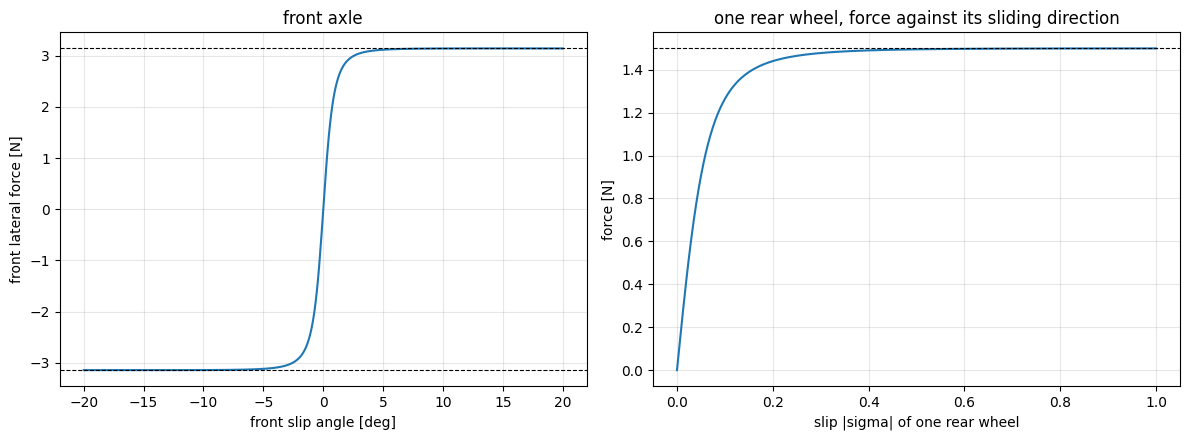

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
a = np.radians(np.linspace(-20, 20, 400))
ax[0].plot(np.degrees(a), p[0] * NF * np.sin(p[4] * np.arctan(p[1] * a)))
ax[0].axhline(p[0] * NF, ls='--', color='k', lw=0.8)
ax[0].axhline(-p[0] * NF, ls='--', color='k', lw=0.8)
ax[0].set_xlabel('front slip angle [deg]')
ax[0].set_ylabel('front lateral force [N]')
ax[0].set_title('front axle')
s = np.linspace(0, 1, 400)
ax[1].plot(s, p[2] * NR / 2 * np.sin(p[4] * np.arctan(p[3] * s)))
ax[1].axhline(p[2] * NR / 2, ls='--', color='k', lw=0.8)
ax[1].set_xlabel('slip |sigma| of one rear wheel')
ax[1].set_ylabel('force [N]')
ax[1].set_title('one rear wheel, force against its sliding direction')
for x in ax:
    x.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Validation

Two ways. Open loop over the whole run, which is a hard test inside the donut:
there small errors grow and the simulated car wanders from the real one. And
1 s ahead from the measured state, restarted every second, which is how the
NMPC will use the model.

In [6]:
def horizon_errors(p, df, h=1.0):
    er, eb, rr = [], [], []
    for a in np.arange(df['t'].iloc[0], df['t'].iloc[-1] - h, h):
        seg = df[(df['t'] >= a) & (df['t'] <= a + h)].reset_index(drop=True)
        s = simulate(p, seg)
        er.append(s[:, 1] - seg['r'])
        eb.append(beta_deg(s, seg) - seg['beta_cg'])
        rr.append(seg['r'])
    return np.concatenate(er), np.concatenate(eb), np.concatenate(rr)


rows = []
for name, df in runs.items():
    s = simulate(p, df)
    e_full = s[:, 1] - df['r']
    e_h, eb_h, r_h = horizon_errors(p, df)
    span = df['r'].max() - df['r'].min()
    rows.append({'run': name,
                 'yaw rms, full [rad/s]': np.sqrt(np.nanmean(e_full**2)),
                 'yaw NRMSE, full': np.sqrt(np.nanmean(e_full**2)) / span,
                 'sideslip rms, full [deg]': np.sqrt(np.nanmean((beta_deg(s, df) - df['beta_cg'])**2)),
                 'yaw rms, 1 s [rad/s]': np.sqrt(np.nanmean(e_h**2)),
                 'yaw NRMSE, 1 s': np.sqrt(np.nanmean(e_h**2)) / span,
                 'sideslip rms, 1 s [deg]': np.sqrt(np.nanmean(eb_h**2))})
validation = pd.DataFrame(rows).round(3)
validation

,run,"yaw rms, full [rad/s]","yaw NRMSE, full","sideslip rms, full [deg]","yaw rms, 1 s [rad/s]","yaw NRMSE, 1 s","sideslip rms, 1 s [deg]"
0,id_steps,0.120,0.171,1.772,0.120,0.170,1.757
1,id_chirp,0.139,0.241,1.477,0.142,0.246,1.490
2,id_drift,0.273,0.098,3.129,0.340,0.122,3.216
3,val_steps,0.115,0.121,1.839,0.117,0.123,1.807
4,val_chirp,0.131,0.183,1.657,0.132,0.184,1.598
5,val_drift,0.907,0.322,9.729,0.415,0.147,3.175
6,release,1.526,0.454,23.810,0.451,0.134,4.316


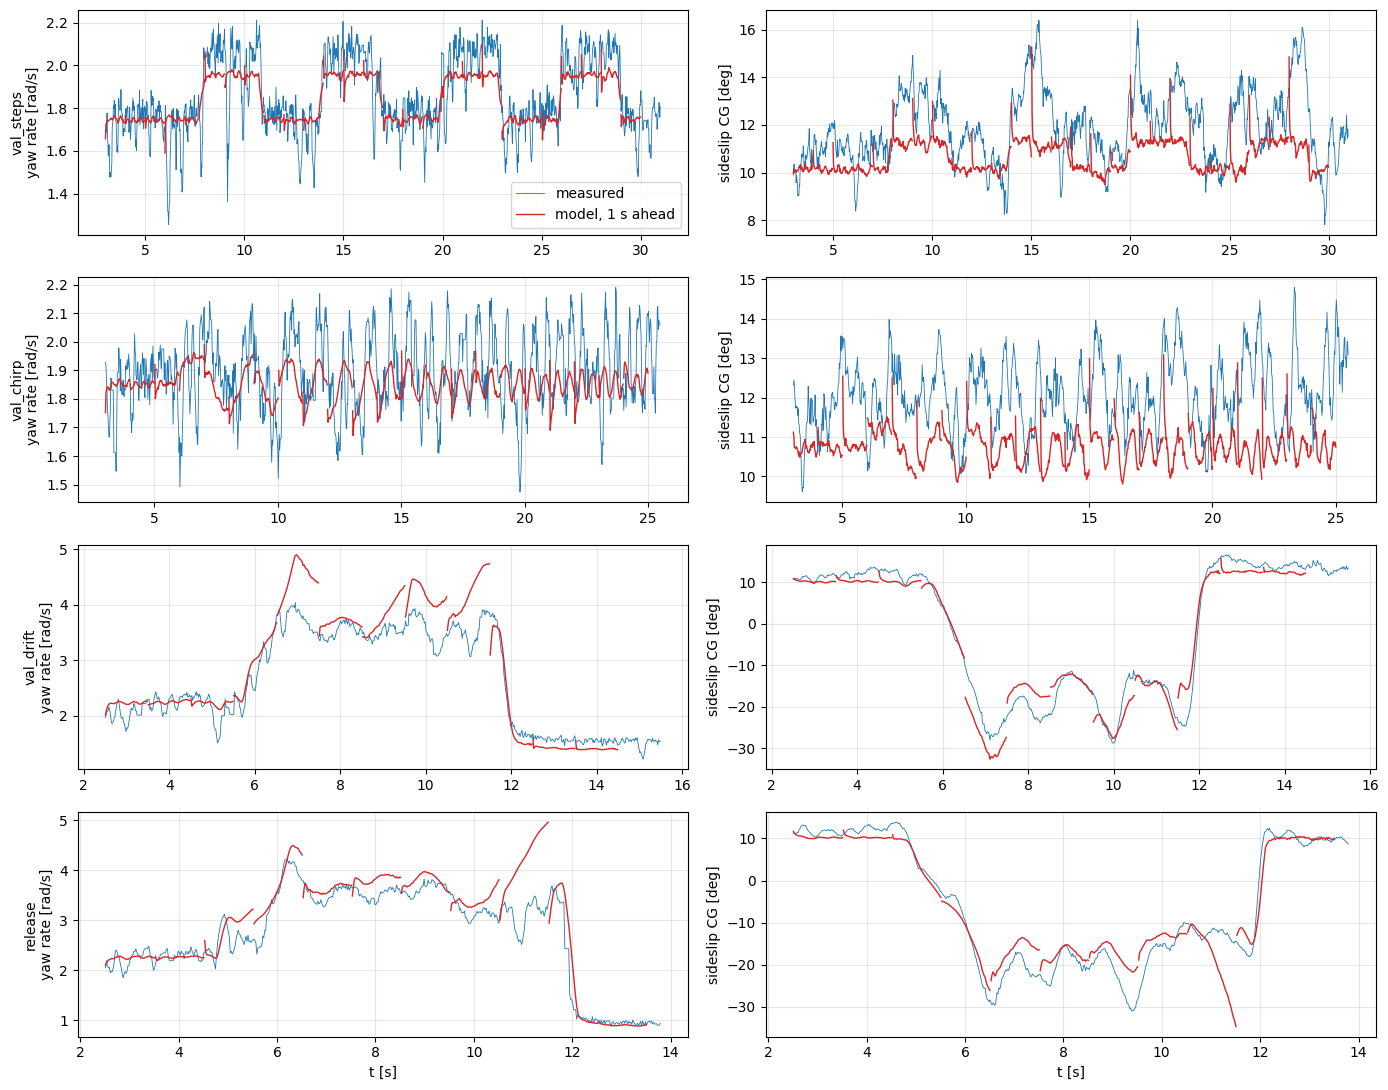

In [7]:
fig, ax = plt.subplots(4, 2, figsize=(14, 11))
for k, name in enumerate(['val_steps', 'val_chirp', 'val_drift', 'release']):
    df = runs[name]
    ax[k, 0].plot(df['t'], df['r'], lw=0.6, label='measured')
    ax[k, 1].plot(df['t'], df['beta_cg'], lw=0.6, label='measured')
    for a in np.arange(df['t'].iloc[0], df['t'].iloc[-1] - 1.0, 1.0):
        seg = df[(df['t'] >= a) & (df['t'] <= a + 1.0)].reset_index(drop=True)
        s = simulate(p, seg)
        ax[k, 0].plot(seg['t'], s[:, 1], color='C3', lw=1)
        ax[k, 1].plot(seg['t'], beta_deg(s, seg), color='C3', lw=1)
    ax[k, 0].set_ylabel(f'{name}\nyaw rate [rad/s]')
    ax[k, 1].set_ylabel('sideslip CG [deg]')
    for x in ax[k]:
        x.grid(alpha=0.3)
ax[0, 0].legend(['measured', 'model, 1 s ahead'])
ax[3, 0].set_xlabel('t [s]')
ax[3, 1].set_xlabel('t [s]')
plt.tight_layout()
plt.show()

## Result

One parameter set covers grip, the donut and the release. 1 s ahead, on the
validation runs: yaw rate within 0.12-0.13 rad/s in grip and 0.42-0.45 rad/s in
the drift (NRMSE 12-18%), sideslip within 1.6-1.8 deg in grip and 3.2-4.3 deg in
the drift. Open loop over a whole run it stays close in grip, but inside the
donut the simulated car wanders off (val_drift 0.9 rad/s): the drift is
sensitive, and the model is good for the short horizons an MPC uses, not for
replaying a whole drift.

What it misses: the model sideslip in grip runs ~1.5 deg under the video, a
constant offset (camera tilt, or the CG position); it overshoots the yaw rate on
drift entry; and when the steering opens inside the donut (release, 10-11.5 s)
it predicts a spin the car did not do.

Still provisional: the steering map at 0.40 / 0.46 rad and the steering lag,
both to be measured directly, then refit.